<a href="https://colab.research.google.com/github/suphitchakh-web/Project_1/blob/main/Team06_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2: Amazon Reviews Analysis — Musical Instruments

## การนำเข้าข้อมูล

In [ ]:
import json, os, re, random, itertools, time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/part_2"

REVIEW_PATH = os.path.join(
    BASE_PATH,
    "Musical_Instruments.csv.gz"
)

META_PATH = os.path.join(
    BASE_PATH,
    "meta_Musical_Instruments.jsonl.gz"
)

print("Review file exists:", os.path.exists(REVIEW_PATH))
print("Metadata file exists:", os.path.exists(META_PATH))

Review file exists: True
Metadata file exists: True


## 1. Setup และการกำหนดค่าการวิเคราะห์

ในขั้นตอนนี้จะเตรียม Python libraries ที่จำเป็น กำหนดค่า RANDOM_SEED และ SAMPLE_N เพื่อให้การสุ่มข้อมูลสามารถทำซ้ำได้ รวมถึงกำหนดตำแหน่งของไฟล์ Review และ Product Metadata ที่ใช้ในการวิเคราะห์

ข้อมูลที่ใช้ประกอบด้วย
- Musical Instruments Review Data
- Musical Instruments Product Metadata

In [ ]:
import os
import pandas as pd
import numpy as np
from google.colab import drive

RANDOM_SEED = 42
SAMPLE_N = 50000
np.random.seed(RANDOM_SEED)

# เชื่อม Google Drive
drive.mount("/content/drive")

# ตำแหน่งโฟลเดอร์ Part 2
BASE_PATH = "/content/drive/MyDrive/part_2"

# ตำแหน่งไฟล์ข้อมูล
REVIEW_PATH = os.path.join(
    BASE_PATH,
    "Musical_Instruments.csv.gz"
)

META_PATH = os.path.join(
    BASE_PATH,
    "meta_Musical_Instruments.jsonl.gz"
)

# ตรวจสอบไฟล์
print("RANDOM_SEED =", RANDOM_SEED)
print("SAMPLE_N =", SAMPLE_N)
print("Review file exists:", os.path.exists(REVIEW_PATH))
print("Metadata file exists:", os.path.exists(META_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RANDOM_SEED = 42
SAMPLE_N = 50000
Review file exists: True
Metadata file exists: True


## 2. ตรวจสอบโครงสร้างของข้อมูล

### 2.1 Review Data

In [ ]:
review_preview = pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    nrows=5
)

print("จำนวนแถวที่อ่านเพื่อดูตัวอย่าง:", len(review_preview))

print("\nColumns:")
print(review_preview.columns.tolist())

print("\nData types:")
print(review_preview.dtypes)

print("\nตัวอย่าง Review Data:")
display(review_preview)

จำนวนแถวที่อ่านเพื่อดูตัวอย่าง: 5

Columns:
['user_id', 'parent_asin', 'rating', 'timestamp']

Data types:
user_id         object
parent_asin     object
rating         float64
timestamp        int64
dtype: object

ตัวอย่าง Review Data:


,user_id,parent_asin,rating,timestamp
0,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B003LPTAYI,5.0,1452650586000
1,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B0040FJ27S,4.0,1384912482000
2,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B06XP6TDVY,3.0,1558567365290
3,AEM663T6XHZFWLODF4US2RCOCUSA,B00WJ3HL5I,3.0,1607055693671
4,AFJTRBXMURLHS5EGNXLUHDHIZRFQ,B07T9NM5QR,5.0,1622595785255


### 2.2 Product Metadata

In [ ]:
meta_preview = pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    nrows=5
)

print("จำนวนแถวที่อ่านเพื่อดูตัวอย่าง:", len(meta_preview))

print("\nColumns:")
print(meta_preview.columns.tolist())

print("\nData types:")
print(meta_preview.dtypes)

print("\nตัวอย่าง Product Metadata:")
display(meta_preview)

จำนวนแถวที่อ่านเพื่อดูตัวอย่าง: 5

Columns:
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']

Data types:
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together    float64
dtype: object

ตัวอย่าง Product Metadata:


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Musical Instruments,Pearl Export Lacquer EXL725S/C249 5-Piece New ...,4.2,22,[Item may ship in more than one box and may ar...,[Introducing the best selling drum set of all ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Best Selling Drum Set of All Time'...,Pearl,"[Musical Instruments, Drums & Percussion, Drum...","{'Item Weight': '33 pounds', 'Product Dimensio...",B01M4HO6RK,NaN
1,Musical Instruments,Behringer EUROPOWER EPQ900 Professional 900 Wa...,4.0,13,[2 x 390 Watts into 4 Ohms; 2 x 245 Watts into...,"[BEHRINGER EUROPOWER EPQ900, Professional 900-...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Behringer,"[Musical Instruments, Live Sound & Stage, Powe...","{'Item Weight': '10.8 pounds', 'Product Dimens...",B00508JFE4,NaN
2,Musical Instruments,Washburn Classical Series Acoustic Electric Cu...,3.6,15,[The Washburn is truly a professional instrume...,[C64SCE CLASSICAL GUITAR The cutaway allows ac...,399.0,[{'thumb': 'https://m.media-amazon.com/images/...,[],Washburn,"[Musical Instruments, Guitars]","{'Item Weight': '5.98 pounds', 'Product Dimens...",B000S5JGMU,NaN
3,Musical Instruments,"VocoPro, plug in, Black, 21.00 x 21.00 x 23.00...",3.5,7,"[Includes one microphone and one receiver, Can...",[VocoPro UHF-18 DIAMOND - N Wireless Microphon...,112.0,[{'thumb': 'https://m.media-amazon.com/images/...,[],VocoPro,"[Musical Instruments, Live Sound & Stage, PA S...","{'Item Weight': '2.29 pounds', 'Product Dimens...",B00B2HLWZW,NaN
4,Musical Instruments,Shure SM7B Vocal Dynamic Microphone for Broadc...,4.9,9512,[ONE MICROPHONE FOR EVERYTHING - Studio Record...,"[The SM7B dynamic microphone has a smooth, fla...",399.0,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Shure SM7B Mic Demonstration', 'ur...",Shure,"[Musical Instruments, Microphones & Accessorie...","{'Item Weight': '2.7 pounds', 'Product Dimensi...",B0B89ZSYS7,NaN


## 3. ตรวจสอบคุณภาพของข้อมูล



### 3.1 ตรวจสอบคุณภาพของ Review Data

ในขั้นตอนนี้จะตรวจสอบคุณภาพของ Review Data ทั้งชุดก่อนนำไปใช้ในการวิเคราะห์ โดยตรวจสอบจำนวนข้อมูลทั้งหมด Missing Values, Duplicate Records, การกระจายของ Rating และช่วงของ Timestamp เนื่องจาก Review Data มีจำนวนหลายล้าน records จึงใช้วิธีอ่านข้อมูลเป็นส่วน ๆ (chunks) เพื่อช่วยลดการใช้หน่วยความจำของ Google Colab และยังสามารถตรวจสอบข้อมูลได้ครบทั้ง Dataset

In [ ]:
# กำหนดตัวแปรสำหรับเก็บผลการตรวจสอบ
total_rows = 0

missing_counts = {
    "user_id": 0,
    "parent_asin": 0,
    "rating": 0,
    "timestamp": 0
}

rating_counts = {}

duplicate_count = 0

min_timestamp = None
max_timestamp = None

chunk_size = 100000

# อ่าน Review Data เป็น chunks
for chunk in pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    chunksize=chunk_size
):
    total_rows += len(chunk)

    # Missing Values
    for col in missing_counts:
        missing_counts[col] += chunk[col].isna().sum()

    # Rating distribution
    counts = chunk["rating"].value_counts()

    for rating, count in counts.items():
        rating_counts[rating] = rating_counts.get(rating, 0) + count

    # Duplicate ภายในแต่ละ chunk
    duplicate_count += chunk.duplicated().sum()

    # Timestamp range
    chunk_min = chunk["timestamp"].min()
    chunk_max = chunk["timestamp"].max()

    if min_timestamp is None or chunk_min < min_timestamp:
        min_timestamp = chunk_min

    if max_timestamp is None or chunk_max > max_timestamp:
        max_timestamp = chunk_max


# แสดงผล
print("===== Review Data Quality Report =====")

print("\nTotal Reviews:")
print(total_rows)

print("\nMissing Values:")
for col, count in missing_counts.items():
    print(f"{col}: {count}")

print("\nDuplicate Records within chunks:")
print(duplicate_count)

print("\nRating Distribution:")
for rating in sorted(rating_counts):
    print(f"{rating}: {rating_counts[rating]}")

print("\nTimestamp Range:")
print(min_timestamp, "to", max_timestamp)

===== Review Data Quality Report =====

Total Reviews:
2975551

Missing Values:
user_id: 0
parent_asin: 0
rating: 0
timestamp: 0

Duplicate Records within chunks:
0

Rating Distribution:
1.0: 260520
2.0: 129732
3.0: 194567
4.0: 394945
5.0: 1995787

Timestamp Range:
935635892000 to 1694546704987


### สรุปผลการตรวจสอบคุณภาพของ Review Data

จากการตรวจสอบ Review Data ทั้งชุด พบว่ามีข้อมูลทั้งหมด 2,975,551 reviews และไม่พบ Missing Values ในคอลัมน์ `user_id`, `parent_asin`, `rating` และ `timestamp`

การกระจายของ Rating พบว่า Rating 5 มีจำนวนมากที่สุด 1,995,787 reviews รองลงมาคือ Rating 4 จำนวน 394,945 reviews, Rating 1 จำนวน 260,520 reviews, Rating 3 จำนวน 194,567 reviews และ Rating 2 จำนวน 129,732 reviews

สำหรับ Duplicate Records จากการตรวจสอบแบบแบ่งข้อมูลเป็น chunks ไม่พบ duplicate ภายในแต่ละ chunk อย่างไรก็ตาม ผลการตรวจสอบนี้ยังไม่สามารถยืนยันได้ว่าไม่มี duplicate ระหว่างคนละ chunks

Timestamp ของข้อมูลอยู่ในช่วง 935635892000 ถึง 1694546704987 ซึ่งจะนำไปแปลงเป็นรูปแบบวันที่และเวลาในขั้นตอนถัดไป เพื่อเตรียมสำหรับการวิเคราะห์ตามช่วงเวลา

โดยรวม Review Data มีจำนวน records มาก และไม่พบ Missing Values ใน 4 คอลัมน์หลักที่ตรวจสอบ จึงสามารถนำไปตรวจสอบคุณภาพของ Product Metadata และเตรียมข้อมูลสำหรับขั้นตอนถัดไปได้

### 3.2 ตรวจสอบคุณภาพของ Product Metadata

ในขั้นตอนนี้จะตรวจสอบคุณภาพของ Product Metadata ทั้งชุด โดยพิจารณาจำนวนสินค้า Missing Values, Duplicate Records และความครบถ้วนของ `parent_asin` ซึ่งเป็น key สำคัญสำหรับการเชื่อม Product Metadata กับ Review Data ในขั้นตอนถัดไป

เนื่องจาก Product Metadata มีหลายคอลัมน์และบางคอลัมน์เป็นข้อมูลแบบข้อความหรือโครงสร้างที่ซับซ้อน จึงจะตรวจสอบ Missing Values แยกตามคอลัมน์ และตรวจสอบ `parent_asin` เพื่อประเมินความพร้อมสำหรับการ Join กับ Review Data

In [ ]:
# ตัวแปรสำหรับเก็บผลการตรวจสอบ
total_meta_rows = 0

meta_missing_counts = {}
parent_asin_missing = 0
parent_asin_counts = {}

chunk_size = 10000

# อ่าน Product Metadata แบบ chunks
for chunk in pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    chunksize=chunk_size
):
    total_meta_rows += len(chunk)

    # สร้างตัวนับ Missing สำหรับทุก column
    if not meta_missing_counts:
        meta_missing_counts = {
            col: 0 for col in chunk.columns
        }

    # นับ Missing Values
    for col in chunk.columns:
        meta_missing_counts[col] += chunk[col].isna().sum()

    # ตรวจ Missing ของ parent_asin
    parent_asin_missing += chunk["parent_asin"].isna().sum()

    # นับจำนวนครั้งที่แต่ละ parent_asin ปรากฏ
    counts = chunk["parent_asin"].dropna().value_counts()

    for asin, count in counts.items():
        parent_asin_counts[asin] = (
            parent_asin_counts.get(asin, 0) + count
        )


# คำนวณจำนวน parent_asin ที่ไม่ซ้ำ
unique_parent_asin = len(parent_asin_counts)

# คำนวณจำนวน parent_asin ที่ซ้ำ
duplicate_parent_asin = sum(
    count - 1
    for count in parent_asin_counts.values()
    if count > 1
)


print("===== Product Metadata Quality Report =====")

print("\nTotal Products:")
print(total_meta_rows)

print("\nMissing Values:")
for col, count in meta_missing_counts.items():
    print(f"{col}: {count}")

print("\nMissing parent_asin:")
print(parent_asin_missing)

print("\nUnique parent_asin:")
print(unique_parent_asin)

print("\nDuplicate parent_asin Records:")
print(duplicate_parent_asin)

===== Product Metadata Quality Report =====

Total Products:
213593

Missing Values:
main_category: 3392
title: 0
average_rating: 0
rating_number: 0
features: 0
description: 0
price: 128677
images: 0
videos: 0
store: 3556
categories: 0
details: 0
parent_asin: 0
bought_together: 213593
subtitle: 213255
author: 213472

Missing parent_asin:
0

Unique parent_asin:
213593

Duplicate parent_asin Records:
0


### สรุปผลการตรวจสอบคุณภาพของ Product Metadata

จากการตรวจสอบ Product Metadata ทั้งชุด พบว่ามีข้อมูลสินค้า 213,593 records โดยไม่พบ Missing Values ใน `parent_asin` และพบว่า `parent_asin` ทั้ง 213,593 ค่าเป็นค่าที่ไม่ซ้ำกัน จึงมีความพร้อมในการใช้เป็น key สำหรับเชื่อมข้อมูลกับ Review Data

สำหรับ Missing Values พบว่า `price` มี Missing Values จำนวน 128,677 records, `main_category` มี 3,392 records และ `store` มี 3,556 records ขณะที่ `title`, `average_rating`, `rating_number`, `features`, `description`, `images`, `videos`, `categories` และ `details` ไม่พบ Missing Values

นอกจากนี้ `bought_together` ไม่มีข้อมูลในทุก record จากผลการตรวจสอบครั้งนี้ จึงควรพิจารณาว่า column ดังกล่าวไม่จำเป็นต่อการวิเคราะห์ในขั้นตอนถัดไป

โดยรวม Product Metadata มี `parent_asin` ครบถ้วนและไม่พบค่าซ้ำ ทำให้สามารถนำ `parent_asin` ไปใช้เป็น key สำหรับ Join กับ Review Data ได้ อย่างไรก็ตาม Missing Values ใน `price`, `main_category` และ `store` จะต้องนำมาพิจารณาในขั้นตอน Data Cleaning และการวิเคราะห์ต่อไป

### 3.3 ตรวจสอบความสอดคล้องของ `parent_asin` ระหว่าง Review Data และ Product Metadata

`parent_asin` เป็น key ที่ใช้เชื่อม Review Data กับ Product Metadata ดังนั้นก่อนทำการ Join จะตรวจสอบว่า `parent_asin` ที่ปรากฏใน Review Data มีอยู่ใน Product Metadata มากน้อยเพียงใด

การตรวจสอบนี้จะช่วยประเมินความพร้อมของข้อมูลสำหรับการ Join และระบุจำนวน Review ที่อาจไม่สามารถจับคู่กับข้อมูลสินค้าได้ โดยจะใช้ข้อมูล `parent_asin` จาก Product Metadata เป็นชุดอ้างอิง

In [ ]:
# สร้าง set ของ parent_asin จาก Product Metadata
meta_parent_asins = set()

for chunk in pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    chunksize=10000
):
    meta_parent_asins.update(
        chunk["parent_asin"].dropna().unique()
    )

print("จำนวน unique parent_asin ใน Metadata:")
print(len(meta_parent_asins))


# ตรวจ parent_asin จาก Review Data
total_reviews = 0
matched_reviews = 0
unmatched_reviews = 0

review_parent_asins = set()

for chunk in pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    usecols=["parent_asin"],
    chunksize=100000
):
    total_reviews += len(chunk)

    review_asins = set(
        chunk["parent_asin"].dropna().unique()
    )

    review_parent_asins.update(review_asins)

    matched_reviews += chunk["parent_asin"].isin(
        meta_parent_asins
    ).sum()

    unmatched_reviews += (
        ~chunk["parent_asin"].isin(meta_parent_asins)
    ).sum()


# คำนวณเปอร์เซ็นต์
match_rate = matched_reviews / total_reviews * 100
unmatch_rate = unmatched_reviews / total_reviews * 100

print("\n===== Parent ASIN Matching Report =====")
print("Total Reviews:", total_reviews)
print("Matched Reviews:", matched_reviews)
print("Unmatched Reviews:", unmatched_reviews)
print("Match Rate: {:.2f}%".format(match_rate))
print("Unmatch Rate: {:.2f}%".format(unmatch_rate))

print("\nUnique parent_asin in Review Data:")
print(len(review_parent_asins))

จำนวน unique parent_asin ใน Metadata:
213593

===== Parent ASIN Matching Report =====
Total Reviews: 2975551
Matched Reviews: 2975551
Unmatched Reviews: 0
Match Rate: 100.00%
Unmatch Rate: 0.00%

Unique parent_asin in Review Data:
213571


### สรุปผลการตรวจสอบความสอดคล้องของ `parent_asin`

จากการตรวจสอบพบว่า Product Metadata มี unique `parent_asin` จำนวน 213,593 ค่า ขณะที่ Review Data มี unique `parent_asin` จำนวน 213,571 ค่า

เมื่อเปรียบเทียบ `parent_asin` ระหว่างทั้งสอง Dataset พบว่า Review Data จำนวน 2,975,551 records สามารถจับคู่กับ Product Metadata ได้ทั้งหมด โดยมี Matched Reviews จำนวน 2,975,551 records และไม่มี Unmatched Reviews

ดังนั้น Review Data มี Match Rate เท่ากับ 100.00% แสดงว่า `parent_asin` ของ Review ทุก record ที่ตรวจสอบสามารถเชื่อมโยงไปยัง Product Metadata ได้

แม้จำนวน unique `parent_asin` ของ Review Data จะน้อยกว่า Metadata อยู่ 22 ค่า แต่ไม่ส่งผลต่อการจับคู่ Review กับ Metadata เนื่องจาก Review ทุก record มี `parent_asin` ที่พบใน Metadata

ผลการตรวจสอบนี้แสดงให้เห็นว่า `parent_asin` มีความพร้อมสำหรับใช้เป็น key ในขั้นตอน Join ระหว่าง Review Data และ Product Metadata

## 4. Data Cleaning

ในขั้นตอนนี้จะเตรียมข้อมูล Review Data และ Product Metadata ให้พร้อมสำหรับการ Sampling และการ Join โดยจะหลีกเลี่ยงการลบข้อมูลที่ไม่จำเป็น

จากการตรวจสอบก่อนหน้า Review Data ไม่มี Missing Values ในคอลัมน์หลัก ได้แก่ `user_id`, `parent_asin`, `rating` และ `timestamp` ดังนั้นจะไม่ลบ records เนื่องจาก Missing Values

สำหรับ Product Metadata จะเก็บ records ที่มี `parent_asin` ครบถ้วนไว้ทั้งหมด เนื่องจาก `parent_asin` เป็น key ที่ใช้เชื่อมข้อมูลระหว่าง Review Data และ Product Metadata

### 4.1 ตรวจสอบและเตรียม Review Data

Review Data มีข้อมูลจำนวนมาก จึงยังไม่โหลดข้อมูลทั้งหมดเข้าสู่หน่วยความจำในขั้นตอนนี้ แต่จะตรวจสอบชนิดข้อมูลและเงื่อนไขที่จำเป็นต่อการวิเคราะห์ ได้แก่ `rating`, `timestamp` และ `parent_asin`

ข้อมูลที่ผ่านเงื่อนไขจะถือเป็น Valid Review สำหรับขั้นตอน Sampling ต่อไป

In [ ]:
# ตรวจสอบ Review Data และนับจำนวน records ที่ผ่านเงื่อนไข
total_reviews = 0
valid_reviews = 0

invalid_rating = 0
invalid_timestamp = 0
invalid_parent_asin = 0

chunk_size = 100000

for chunk in pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    chunksize=chunk_size
):
    total_reviews += len(chunk)

    # ตรวจเงื่อนไข Rating ต้องอยู่ระหว่าง 1 ถึง 5
    rating_valid = chunk["rating"].between(1, 5)

    # ตรวจ Timestamp ต้องไม่เป็น Missing
    timestamp_valid = chunk["timestamp"].notna()

    # ตรวจ parent_asin ต้องไม่เป็น Missing
    parent_asin_valid = chunk["parent_asin"].notna()

    # นับข้อมูลที่ไม่ผ่านแต่ละเงื่อนไข
    invalid_rating += (~rating_valid).sum()
    invalid_timestamp += (~timestamp_valid).sum()
    invalid_parent_asin += (~parent_asin_valid).sum()

    # Valid Review ต้องผ่านทุกเงื่อนไข
    valid_mask = (
        rating_valid
        & timestamp_valid
        & parent_asin_valid
    )

    valid_reviews += valid_mask.sum()


print("===== Review Data Cleaning Check =====")
print("Total Reviews:", total_reviews)
print("Valid Reviews:", valid_reviews)
print("Invalid Rating:", invalid_rating)
print("Invalid Timestamp:", invalid_timestamp)
print("Invalid parent_asin:", invalid_parent_asin)

===== Review Data Cleaning Check =====
Total Reviews: 2975551
Valid Reviews: 2975551
Invalid Rating: 0
Invalid Timestamp: 0
Invalid parent_asin: 0


### สรุปผลการตรวจสอบและเตรียม Review Data

จากการตรวจสอบ Review Data ทั้งหมด 2,975,551 records พบว่าทุก record ผ่านเงื่อนไขที่กำหนดสำหรับการวิเคราะห์ โดย `rating` อยู่ในช่วง 1–5, `timestamp` ไม่เป็น Missing และ `parent_asin` ไม่เป็น Missing

ไม่พบ Invalid Rating, Invalid Timestamp หรือ Invalid `parent_asin` ดังนั้น Review Data ทั้ง 2,975,551 records หรือ 100% ของข้อมูล สามารถนำไปใช้ในขั้นตอน Sampling และการ Join กับ Product Metadata ได้โดยไม่จำเป็นต้องลบ records จากเงื่อนไขเหล่านี้

### 4.2 ตรวจสอบและเตรียม Product Metadata

Product Metadata มี `parent_asin` ครบถ้วนและไม่พบ `parent_asin` ซ้ำจากการตรวจสอบก่อนหน้า ดังนั้นจะเก็บข้อมูลสินค้าที่มี `parent_asin` ครบถ้วนไว้สำหรับการ Join กับ Review Data

ในขั้นตอนนี้จะตรวจสอบความพร้อมของข้อมูลสำหรับการวิเคราะห์ โดยเฉพาะ `parent_asin`, `title`, `features` และ `description` ซึ่งเป็นข้อมูลที่สามารถนำมาใช้ประกอบการวิเคราะห์สินค้าและสร้าง Text Features ในขั้นตอนถัดไป

In [ ]:
# ตรวจสอบและเตรียม Product Metadata
meta_valid_rows = 0
meta_invalid_parent_asin = 0

text_columns = ["title", "features", "description"]

text_missing_counts = {
    col: 0 for col in text_columns
}

chunk_size = 10000

for chunk in pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    chunksize=chunk_size
):
    # ตรวจ parent_asin
    parent_asin_valid = chunk["parent_asin"].notna()

    meta_valid_rows += parent_asin_valid.sum()
    meta_invalid_parent_asin += (~parent_asin_valid).sum()

    # ตรวจ Missing Values ของ text columns
    for col in text_columns:
        text_missing_counts[col] += chunk[col].isna().sum()


print("===== Product Metadata Cleaning Check =====")
print("Total Metadata Records:", total_meta_rows)
print("Valid Metadata Records:", meta_valid_rows)
print("Invalid parent_asin:", meta_invalid_parent_asin)

print("\nMissing Values in Text Columns:")
for col, count in text_missing_counts.items():
    print(f"{col}: {count}")

===== Product Metadata Cleaning Check =====
Total Metadata Records: 213593
Valid Metadata Records: 213593
Invalid parent_asin: 0

Missing Values in Text Columns:
title: 0
features: 0
description: 0


### สรุปผลการตรวจสอบและเตรียม Product Metadata

จากการตรวจสอบ Product Metadata ทั้งหมด 213,593 records พบว่า `parent_asin` ครบถ้วนทุก record และไม่มี Invalid `parent_asin`

สำหรับข้อมูลข้อความที่สำคัญต่อการวิเคราะห์ ได้แก่ `title`, `features` และ `description` ไม่พบ Missing Values ในทั้ง 3 columns

ดังนั้น Product Metadata ทั้ง 213,593 records สามารถนำไปใช้สำหรับการ Join กับ Review Data ได้ และข้อมูลข้อความใน `title`, `features` และ `description` มีความพร้อมสำหรับนำไปสร้าง Text Features ในขั้นตอนการวิเคราะห์ต่อไป

### 4.3 Sampling และ Join Review Data กับ Product Metadata

Review Data มีจำนวน 2,975,551 records ซึ่งมีขนาดใหญ่ จึงจะสุ่มตัวอย่างจำนวน `SAMPLE_N = 50,000` records สำหรับการวิเคราะห์เชิงลึก โดยใช้ `RANDOM_SEED` ที่กำหนดไว้ในขั้นตอน Setup เพื่อให้สามารถทำซ้ำผลการสุ่มได้

หลังจาก Sampling จะนำ Review Data ที่ได้มา Join กับ Product Metadata โดยใช้ `parent_asin` เป็น key เพื่อเพิ่มข้อมูลเกี่ยวกับสินค้า เช่น `title`, `features`, `description`, `average_rating` และ `price`

หลังการ Join จะตรวจสอบจำนวน records ก่อนและหลัง Join รวมถึง Join Success Rate เพื่อยืนยันว่าข้อมูลตัวอย่างยังคงสามารถเชื่อมโยงกับ Product Metadata ได้ครบถ้วน

In [ ]:
# ============================================================
# 1. Random Sampling จาก Review Data
# ============================================================

review_sample = pd.read_csv(
    REVIEW_PATH,
    compression="gzip"
).sample(
    n=SAMPLE_N,
    random_state=RANDOM_SEED
).reset_index(drop=True)

print("===== Sampling Result =====")
print("Sample size:", len(review_sample))
print("Expected SAMPLE_N:", SAMPLE_N)


# ============================================================
# 2. อ่าน Product Metadata
# ============================================================

meta = pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip"
)

print("\nProduct Metadata rows:", len(meta))


# ============================================================
# 3. เลือกเฉพาะ columns ที่จำเป็นสำหรับการวิเคราะห์
# ============================================================

meta_selected = meta[
    [
        "parent_asin",
        "title",
        "features",
        "description",
        "average_rating",
        "rating_number",
        "price",
        "store"
    ]
].copy()


# ============================================================
# 4. Join Review Data กับ Product Metadata
# ============================================================

before_join = len(review_sample)

analysis_df = review_sample.merge(
    meta_selected,
    on="parent_asin",
    how="left",
    validate="many_to_one"
)

after_join = len(analysis_df)

matched_rows = analysis_df["title"].notna().sum()
unmatched_rows = analysis_df["title"].isna().sum()

join_success_rate = matched_rows / before_join * 100


# ============================================================
# 5. แสดงผล
# ============================================================

print("\n===== Join Result =====")
print("Rows before Join:", before_join)
print("Rows after Join:", after_join)
print("Matched Reviews:", matched_rows)
print("Unmatched Reviews:", unmatched_rows)
print("Join Success Rate: {:.2f}%".format(join_success_rate))

print("\n===== Analysis Dataset Preview =====")
display(analysis_df.head())

===== Sampling Result =====
Sample size: 50000
Expected SAMPLE_N: 50000

Product Metadata rows: 213593

===== Join Result =====
Rows before Join: 50000
Rows after Join: 50000
Matched Reviews: 50000
Unmatched Reviews: 0
Join Success Rate: 100.00%

===== Analysis Dataset Preview =====


,user_id,parent_asin,rating,timestamp,title,features,description,average_rating,rating_number,price,store
0,AE6LPEJK2J4MMEOJSWJAHRMS6U2Q,B00CBY2T9I,5.0,1429554033000,Tune Pro Clip on CAMO (Camouflage) Tuner -Guit...,"[CAMO colored tuner!, Fully Chromatic Tuner - ...","[A fantastic new tuner that's fully chromatic,...",3.9,21,None,Tune Pro
1,AHW47JDBNZNTODMUFZNY433FISDQ,B07MVRLPFW,5.0,1626046978013,Revv G4 Preamp/Overdrive/Distortion Pedal Red,[Preamp/Overdrive/Disttion Pedal f Electric Gu...,"[Fat, Saturated Amp-in-a-box Distortion]",4.3,79,None,Revv Amplification
2,AF7OTEOLODNNEZ5DANN4E3L3J4RQ,B07BV6HJPD,5.0,1535362957836,"Liberty Imports 23"" Acoustic Guitar, Kids 6 St...",[MINI GUITAR FOR LEARNING: This beginner's aco...,[],4.0,458,29.97,Liberty Imports
3,AGID6ECJWQLAZGKMOEA7CU3V7DRQ,B073RTT48C,5.0,1655065283860,Hipshot 6GLO Grip-Lock Locking Guitar Tuning M...,"[3+3 headstock configuration, Grip lock, 18:1 ...",[Keep your shredder in precise tuning. Hipshot...,4.8,1231,79.94,Hipshot
4,AHBLH67EE2QDH34EJI642YUJ5J3Q,B0B3VKB2C1,3.0,1527701548877,MusicNomad MN117 Cymbal Cleaner & Drum Detaile...,"[Acid-free cymbal cleaner works to clean, poli...",[Small in size but big in results we developed...,4.2,301,9.99,MusicNomad


### สรุปผลการ Sampling และ Join

จากการสุ่ม Review Data ด้วย `SAMPLE_N = 50,000` และ `RANDOM_SEED = 42` ได้ข้อมูลตัวอย่างจำนวน 50,000 reviews ตามที่กำหนด

เมื่อนำ Review Data ไป Join กับ Product Metadata ด้วย `parent_asin` พบว่าจำนวน records ก่อนและหลัง Join เท่ากันที่ 50,000 records โดยสามารถจับคู่กับ Product Metadata ได้ครบทั้ง 50,000 reviews และไม่พบ Unmatched Reviews

ดังนั้น Join Success Rate เท่ากับ 100.00% และสามารถใช้ `analysis_df` เป็น Dataset หลักสำหรับการวิเคราะห์ในขั้นตอนถัดไปได้

## 5. Exploratory Data Analysis (EDA) (ณิรดา)

### 5.1 การกระจายของ Rating

===== Rating Distribution =====
rating
1.0     4393
2.0     2189
3.0     3296
4.0     6652
5.0    33470
Name: count, dtype: int64

===== Rating Percentage =====
Rating 1: 8.79%
Rating 2: 4.38%
Rating 3: 6.59%
Rating 4: 13.30%
Rating 5: 66.94%


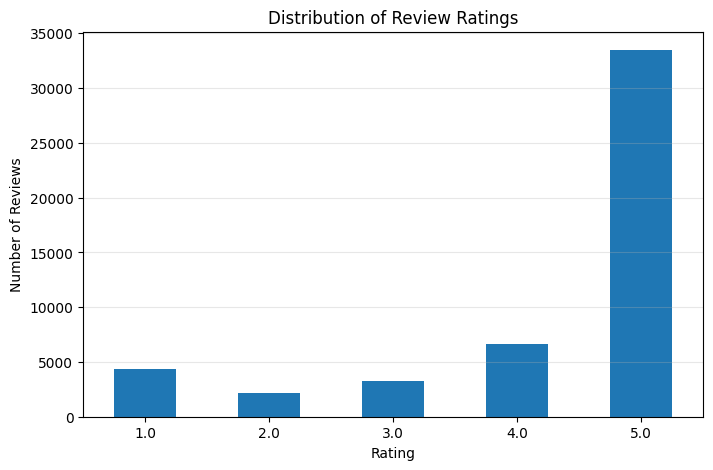

In [ ]:
# วัตถุประสงค์: ดูว่าในตัวอย่าง 50,000 reviews ลูกค้าให้คะแนนระดับใดมากที่สุด
# ============================================================
# 5.1 การกระจายของ Rating
# ============================================================

rating_counts = (
    analysis_df["rating"]
    .value_counts()
    .sort_index()
)

print("===== Rating Distribution =====")
print(rating_counts)

# Percentage
rating_percent = (
    analysis_df["rating"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\n===== Rating Percentage =====")
for rating, percent in rating_percent.items():
    print(f"Rating {rating:.0f}: {percent:.2f}%")

# Plot
plt.figure(figsize=(8, 5))

rating_counts.plot(
    kind="bar"
)

plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

#### สรุปผลการวิเคราะห์การกระจายตัวของ Rating

จากการวิเคราะห์การกระจายของ `Rating` พบว่า Rating แต่ละระดับมีจำนวนแตกต่างกัน โดยสามารถเห็นได้ชัดว่าคะแนนระดับ `5.0` มีจำนวน Review มากที่สุด ซึ่งช่วยสะท้อนว่าลูกค้าส่วนมากให้คะแนนสินค้าใน `ระดับดีมาก` จากกลุ่มตัวอย่าง 50,000 reviews

### 5.2 การกระจายของ Reviews ตาม Product

In [ ]:
# วัตถุประสงค์: ดูว่าสินค้าแต่ละรายการได้รับ Review มากน้อยแตกต่างกันอย่างไร และหา Product ที่มีจำนวน Reviews สูงสุดใน Sample
# ============================================================
# 5.2 การกระจายของ Reviews ตาม Product
# ============================================================

product_review_counts = (
    analysis_df
    .groupby(["parent_asin", "title"])
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

print("===== Top 10 Products by Number of Reviews =====")
display(product_review_counts.head(10))

===== Top 10 Products by Number of Reviews =====


,parent_asin,title,review_count
20582,B09857JRP2,GLS Audio Instrument Cable - Amp Cord for Bass...,126
21708,B09W4F2X6S,"BONAOK Wireless Bluetooth Karaoke Microphone, ...",121
24256,B0C6H9T5T6,"Blue Yeti USB Microphone for PC, Mac, Gaming, ...",108
22850,B0BHSG5C3G,"Snark SN5X Clip-On Tuner for Guitar, Bass & Vi...",97
22620,B0BCK6L7S5,"Donner Guitar Delay Pedal, Yellow Fall Analog ...",97
6412,B00DY1F2CS,"Neewer Microphone Arm Stand, Suspension Boom S...",94
23530,B0BSGM6CQ9,Ernie Ball Mondo Slinky Nickelwound Electric G...,87
23614,B0BTR12G3V,Best Choice Products 38in Beginner All Wood Ac...,86
12101,B06ZYJ6SJZ,FIFINE USB Podcast Condenser Microphone Record...,86
19155,B08JMQR2JK,On Stage XCG4 Velveteen Padded Tubular Guitar ...,82


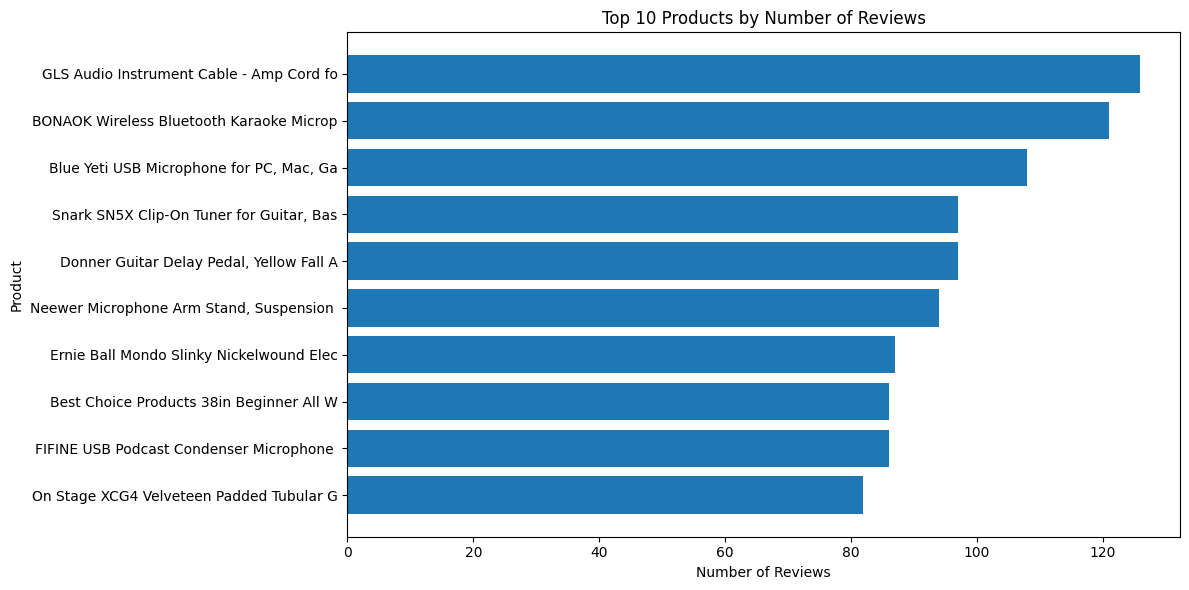

In [ ]:
# Top 10 Products
top10_products = product_review_counts.head(10).copy()

# ตัดชื่อสินค้าให้สั้นลงเพื่อให้กราฟอ่านง่าย
top10_products["short_title"] = (
    top10_products["title"]
    .str[:40]
)

plt.figure(figsize=(12, 6))

plt.barh(
    top10_products["short_title"][::-1],
    top10_products["review_count"][::-1]
)

plt.title("Top 10 Products by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [ ]:
unique_products = analysis_df["parent_asin"].nunique()

print("Number of unique products:", unique_products)
print("Total reviews:", len(analysis_df))

average_reviews_per_product = (
    len(analysis_df) / unique_products
)

print(
    "Average reviews per product:",
    round(average_reviews_per_product, 2)
)

Number of unique products: 24453
Total reviews: 50000
Average reviews per product: 2.04


###สรุปผลการกระจายของ Reviews ตาม Product
จากการวิเคราะห์ข้อมูล Review จำนวนทั้งหมด 50,000 รายการ พบว่ามีสินค้า `(Unique Products)` จำนวน `24,453 รายการ` โดยมีค่าเฉลี่ยจำนวน Reviews ต่อ Product เท่ากับ `2.04` Reviews ต่อ Product

ผลการวิเคราะห์แสดงให้เห็นว่า แม้ข้อมูลที่นำมาวิเคราะห์จะมีจำนวน Reviews ถึง 50,000 รายการ แต่ Reviews เหล่านี้กระจายอยู่ใน Product จำนวนมาก ทำให้จำนวน `Reviews เฉลี่ยต่อ Product` อยู่ใน `ระดับค่อนข้างต่ำ` ที่ 2.04 Reviews ต่อ Product สะท้อนให้เห็นว่าในกลุ่มตัวอย่างมี Product จำนวนมากที่ได้รับ Reviews เพียงไม่กี่รายการ

ดังนั้น การวิเคราะห์จำนวน Reviews ตาม Product จึงสามารถใช้เพื่อศึกษาว่า Product ใดมีจำนวน Reviews สูงกว่าสินค้าอื่น และช่วยให้เห็นลักษณะการกระจายตัวของ Reviews ภายในกลุ่มตัวอย่างได้ชัดเจนยิ่งขึ้น

### 5.3 การวิเคราะห์ Reviews ตามช่วงเวลา

In [ ]:
# ============================================================
# 5.3 การวิเคราะห์ Reviews ตามช่วงเวลา
# ============================================================

analysis_df["review_date"] = pd.to_datetime(
    analysis_df["timestamp"],
    unit="ms"
)

# ตรวจสอบวันที่
print("===== Review Date Range =====")
print("Start:", analysis_df["review_date"].min())
print("End:", analysis_df["review_date"].max())

===== Review Date Range =====
Start: 2001-01-04 15:16:19
End: 2023-09-05 12:24:12.521000


### สรุปผลการวิเคราะห์ Reviews ตามช่วงเวลา
จากการแปลงข้อมูล `timestamp` ให้อยู่ในรูปแบบวันที่ พบว่า Review ในกลุ่มตัวอย่างมีช่วงเวลาตั้งแต่วันที่ 4 มกราคม 2001 เวลา 15:16:19 จนถึงวันที่ 5 กันยายน 2023 เวลา 12:24:12.521

In [ ]:
# จำนวน Reviews รายปี

reviews_by_year = (
    analysis_df
    .groupby(analysis_df["review_date"].dt.year)
    .size()
)

print("===== Reviews by Year =====")
print(reviews_by_year)

===== Reviews by Year =====
review_date
2001       1
2002       2
2003       3
2004       8
2005      13
2006      18
2007      48
2008      84
2009      94
2010     276
2011     534
2012     900
2013    1997
2014    2859
2015    4009
2016    4641
2017    4276
2018    4562
2019    5602
2020    6372
2021    6452
2022    5063
2023    2186
dtype: int64


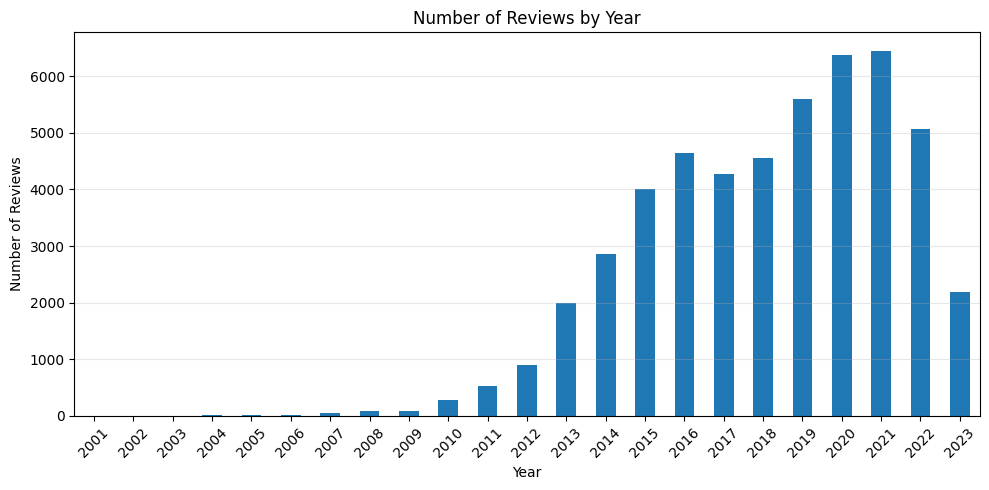

In [ ]:
plt.figure(figsize=(10, 5))

reviews_by_year.plot(
    kind="bar"
)

plt.title("Number of Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### จำนวน Reviews รายปี

เมื่อพิจารณาจำนวน `Reviews จำแนกตามปี` พบว่าจำนวน Reviews มี`แนวโน้มเพิ่มขึ้นอย่างต่อเนื่อง`ในช่วงแรกของข้อมูล โดยในปี 2001 มีเพียง 1 Review และเพิ่มขึ้นเป็น 13 Reviews ในปี 2005, 94 Reviews ในปี 2009 และ 276 Reviews ในปี 2010

หลังจากนั้นจำนวน Reviews `เพิ่มขึ้นอย่างชัดเจน` โดยมี 534 Reviews ในปี 2011, 900 Reviews ในปี 2012, 1,997 Reviews ในปี 2013, 2,859 Reviews ในปี 2014 และ 4,009 Reviews ในปี 2015

ในปี 2016 มีจำนวน 4,641 Reviews และปี 2017 มี 4,276 Reviews ขณะที่ปี 2018 มี 4,562 Reviews จากนั้นจำนวน Reviews เพิ่มขึ้นอีกครั้งเป็น 5,602 Reviews ในปี 2019 และ 6,372 Reviews ในปี 2020

ปี `2021 เป็นปีที่มีจำนวน Reviews สูงที่สุด` ในข้อมูลชุดนี้ โดยมีจำนวน 6,452 Reviews หลังจากนั้นจำนวน Reviews ลดลงเป็น 5,063 Reviews ในปี 2022 และเหลือ 2,186 Reviews ในปี 2023 อย่างไรก็ตาม ข้อมูลปี 2023 ครอบคลุมเพียงช่วงวันที่ 1 มกราคมถึง 5 กันยายน จึงไม่ควรนำจำนวน Reviews ของปี 2023 ไปเปรียบเทียบกับปีที่มีข้อมูลครบทั้งปีโดยตรง

โดยสรุป ช่วงปี 2019–2022 เป็นช่วงที่มีจำนวน Reviews ในระดับสูงเมื่อเปรียบเทียบกับช่วงก่อนหน้า และปี 2021 มีจำนวน Reviews สูงสุดในกลุ่มตัวอย่างที่ 6,452 Reviews

In [ ]:
reviews_by_month = (
    analysis_df
    .set_index("review_date")
    .resample("M")
    .size()
)

print("===== Monthly Reviews =====")
display(reviews_by_month.head(20))

===== Monthly Reviews =====


/tmp/ipykernel_1099/2015618365.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,0
review_date,
2001-01-31,1
2001-02-28,0
2001-03-31,0
2001-04-30,0
2001-05-31,0
2001-06-30,0
2001-07-31,0
2001-08-31,0
2001-09-30,0


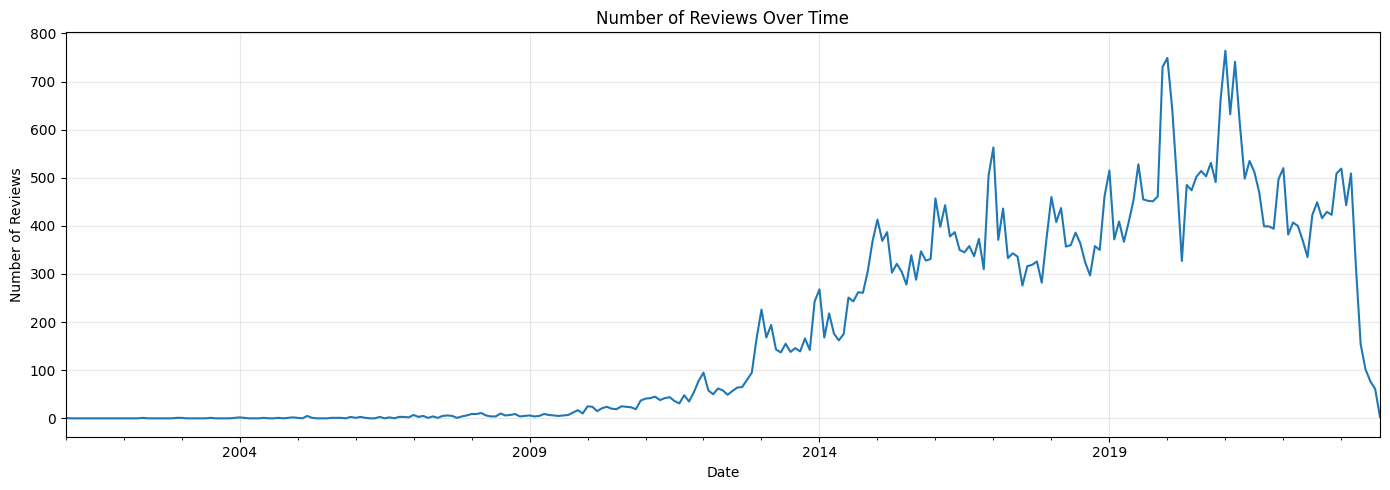

In [ ]:
plt.figure(figsize=(14, 5))

reviews_by_month.plot()

plt.title("Number of Reviews Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1099/3152686850.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["rating"]


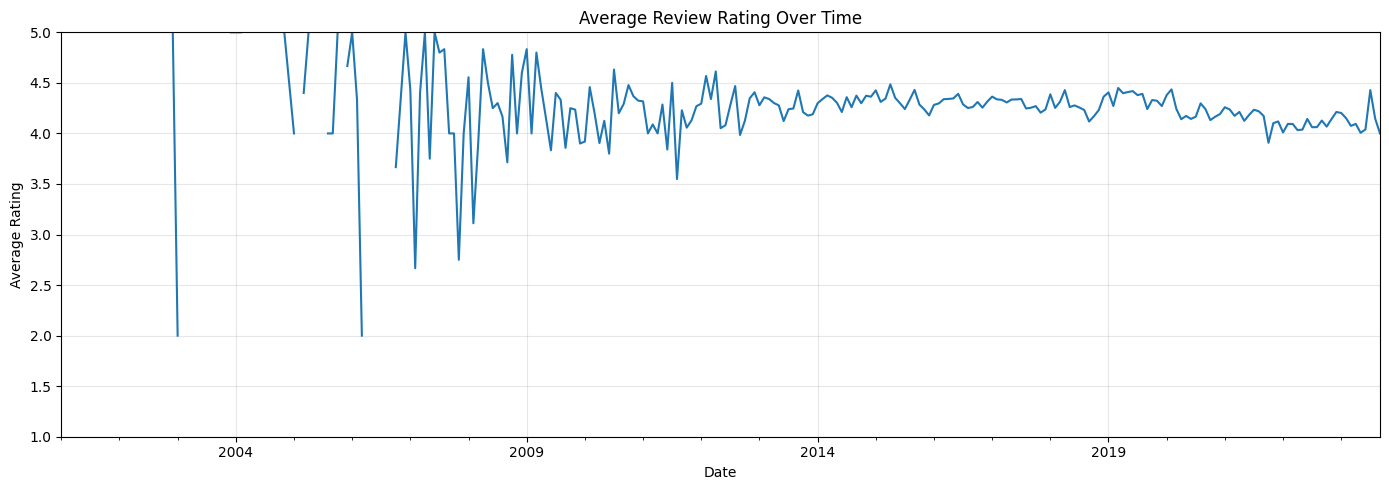

In [ ]:
monthly_rating = (
    analysis_df
    .set_index("review_date")
    .resample("M")["rating"]
    .mean()
)

plt.figure(figsize=(14, 5))

monthly_rating.plot()

plt.title("Average Review Rating Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.ylim(1, 5)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### จำนวน Review รายเดือน

การวิเคราะห์รายเดือน พบว่า Reviews มีการกระจายอยู่ในหลายช่วงเวลา โดยในช่วงต้นของ Dataset มี`บางเดือนที่ไม่มี Reviews` และ`บางเดือนมี Reviews เพียงเล็กน้อย` ซึ่งสอดคล้องกับจำนวน Reviews รายปีที่มีจำนวนน้อยในช่วงปีแรก ๆ ของข้อมูล

### 5.4 การเปรียบเทียบ Review Rating กับ Product Average Rating

In [ ]:
# ============================================================
# 5.4 Review Rating vs Product Average Rating
# ============================================================

comparison = analysis_df[
    ["rating", "average_rating"]
].dropna()

print("===== Rating Comparison =====")
display(
    comparison.describe()
)

===== Rating Comparison =====


,rating,average_rating
count,50000.000000,50000.000000
mean,4.252340,4.373490
std,1.279663,0.412278
min,1.000000,1.000000
25%,4.000000,4.200000
50%,5.000000,4.500000
75%,5.000000,4.600000
max,5.000000,5.000000


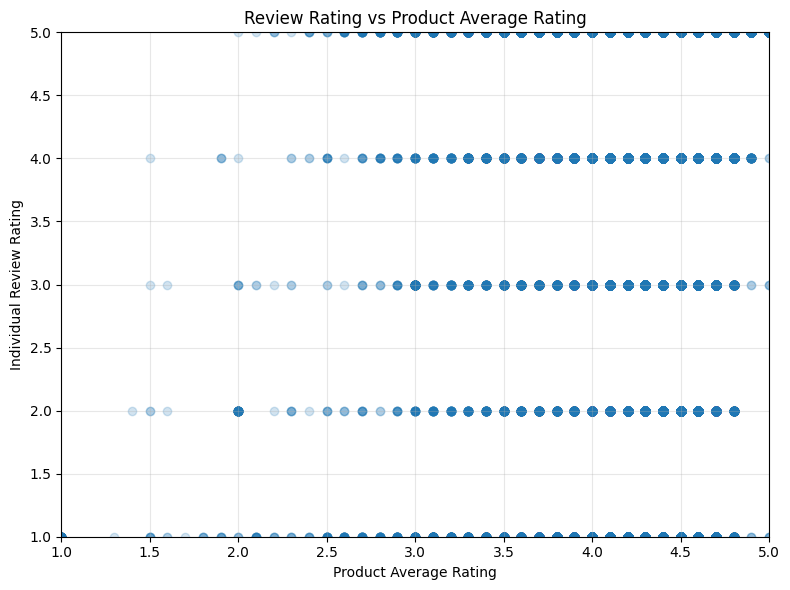

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    comparison["average_rating"],
    comparison["rating"],
    alpha=0.2
)

plt.title(
    "Review Rating vs Product Average Rating"
)

plt.xlabel("Product Average Rating")
plt.ylabel("Individual Review Rating")

plt.xlim(1, 5)
plt.ylim(1, 5)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("===== Mean Comparison =====")

print(
    "Mean Individual Review Rating:",
    round(comparison["rating"].mean(), 3)
)

print(
    "Mean Product Average Rating:",
    round(comparison["average_rating"].mean(), 3)
)

===== Mean Comparison =====
Mean Individual Review Rating: 4.252
Mean Product Average Rating: 4.373


In [ ]:
comparison = comparison.copy()

comparison["rating_difference"] = (
    comparison["rating"]
    - comparison["average_rating"]
)

print("===== Rating Difference =====")

display(
    comparison["rating_difference"].describe()
)

===== Rating Difference =====


,rating_difference
count,50000.000000
mean,-0.121150
std,1.224492
min,-4.000000
25%,-0.500000
50%,0.300000
75%,0.600000
max,3.000000


### ผลการวิเคราะห์การเปรียบเทียบ Review Rating กับ Product Average Rating

ผลการวิเคราะห์พบว่า `Individual Review Rating` มีค่าเฉลี่ยเท่ากับ `4.252` คะแนน และมีส่วนเบี่ยงเบนมาตรฐานเท่ากับ `1.280`โดยมีค่าต่ำสุด 1 คะแนน และสูงสุด 5 คะแนน

ในขณะที่ `Product Average Rating` มีค่าเฉลี่ยเท่ากับ `4.373` คะแนน และมีส่วนเบี่ยงเบนมาตรฐานเท่ากับ `0.412` โดยมีค่าต่ำสุด 1 คะแนน และสูงสุด 5 คะแนน

เมื่อเปรียบเทียบค่าเฉลี่ย พบว่า Product Average Rating มี`ค่าเฉลี่ยสูงกว่า` Individual Review Rating โดยมีค่าแตกต่างกันประมาณ 0.121 คะแนน

กล่าวคือ ค่าเฉลี่ยของคะแนน Review รายบุคคลอยู่ที่ 4.252 ในขณะที่ค่าเฉลี่ยของ Product Rating อยู่ที่ 4.373

In [ ]:
comparison["comparison_group"] = np.where(
    comparison["rating_difference"] > 0,
    "Review > Product Average",
    np.where(
        comparison["rating_difference"] < 0,
        "Review < Product Average",
        "Review = Product Average"
    )
)

comparison_counts = (
    comparison["comparison_group"]
    .value_counts()
)

print("===== Comparison Groups =====")
print(comparison_counts)

===== Comparison Groups =====
comparison_group
Review > Product Average    33324
Review < Product Average    15094
Review = Product Average     1582
Name: count, dtype: int64


### แบ่งข้อมูล 3 กลุ่ม

เมื่อสร้างตัวแปร rating_difference จากสูตร

`Rating Difference` = `Individual Review Rating − Product Average Rating`

พบว่าค่าเฉลี่ยของความแตกต่างเท่ากับ -0.121 ซึ่งสอดคล้องกับผลการเปรียบเทียบค่าเฉลี่ยข้างต้น นอกจากนี้ ค่าต่ำสุดของความแตกต่างเท่ากับ -4.00 และค่าสูงสุดเท่ากับ 3.00 โดยค่ามัธยฐานอยู่ที่ 0.30

เมื่อแบ่งข้อมูลออกเป็น 3 กลุ่มตามความแตกต่างระหว่าง Review Rating กับ Product Average Rating พบว่า

`Review > Product Average จำนวน 33,324 Reviews`

`Review < Product Average จำนวน 15,094 Reviews`

`Review = Product Average จำนวน 1,582 Reviews`

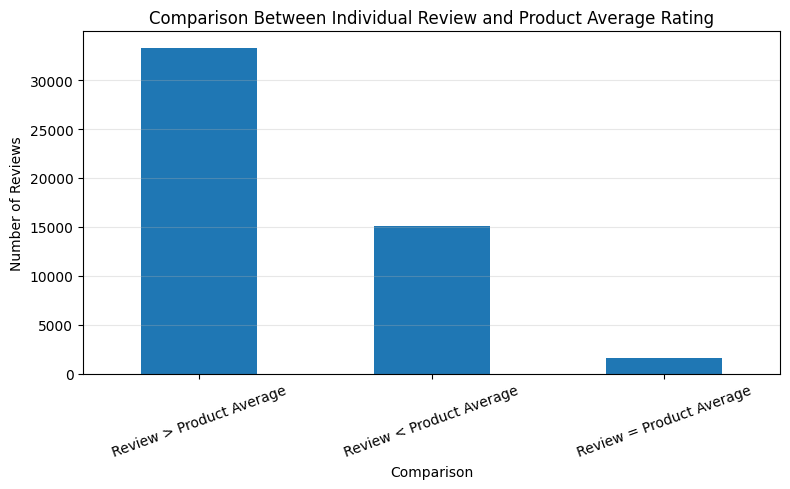

In [ ]:
plt.figure(figsize=(8, 5))

comparison_counts.plot(
    kind="bar"
)

plt.title(
    "Comparison Between Individual Review and Product Average Rating"
)

plt.xlabel("Comparison")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### สรุปผลการวิเคราะห์การเปรียบเทียบ Review Rating กับ Product Average Rating

ผลการวิเคราะห์ส่วนนี้แสดงให้เห็นว่า แม้ค่าเฉลี่ยของ Individual Review Rating จะต่ำกว่าค่าเฉลี่ยของ Product Average Rating แต่เมื่อพิจารณาเป็นราย Review กลับพบว่า Reviews จำนวนมากมีคะแนนสูงกว่า Product Average Rating ของสินค้านั้น ๆ ทั้งนี้ ค่า Product Average Rating เป็นค่าที่สรุปในระดับ Product ขณะที่ Individual Review Rating เป็นคะแนนของ Review แต่ละรายการ จึงควรพิจารณาความแตกต่างของระดับข้อมูลดังกล่าวประกอบการตีความผล

### 5.5 สรุปผลการทำ EDA

###ด้าน Product:
พบสินค้า`ไม่ซ้ำกัน 24,453 รายการ` จาก Reviews 50,000 รายการ คิดเป็น`ค่าเฉลี่ย 2.04 Reviews ต่อ Product` แสดงว่า Reviews กระจายอยู่ใน Product จำนวนมาก


###ด้านช่วงเวลา:
ข้อมูล Reviews ครอบคลุมตั้งแต่ ปี 2001–2023 โดยจำนวน Reviews `เพิ่มขึ้น`อย่างชัดเจนในช่วงหลัง และ`สูงสุดในปี 2021` จำนวน 6,452 Reviews



###ด้าน Rating:
คะแนน Review `รายบุคคลมีค่าเฉลี่ย 4.252` ขณะที่ `Product Average Rating มีค่าเฉลี่ย 4.373`
ด้านความแตกต่างของ Rating: พบว่า 33,324 Reviews มีคะแนนสูงกว่า Product Average Rating, 15,094 Reviews มีคะแนนต่ำกว่า และ 1,582 Reviews มีคะแนนเท่ากัน


###สรุปภาพรวม:
EDA แสดงให้เห็นลักษณะการกระจายของ Reviews ตาม Product, ช่วงเวลา และ Rating ซึ่งช่วยให้เข้าใจโครงสร้างและแนวโน้มของข้อมูลก่อนนำไปวิเคราะห์ในขั้นตอนถัดไป

## 6. Text Features (เวฟ)

### 6.1 ตรวจสอบข้อมูล Text จาก Product Metadata

ตรวจสอบความพร้อมของ `title`, `features` และ `description` ใน `analysis_df` (50,000 reviews) โดยนับจำนวนค่าว่าง และแปลง `features` / `description` ซึ่งเป็น list ของข้อความให้เป็นข้อความเดียวก่อนสร้าง Text Features

**ผลการตรวจสอบ:** `title` ว่างเพียง 7 records (0.01%), `features` ว่าง 3,112 records (6.22%) และ `description` ว่าง 17,561 records (35.12%) จึงเลือกใช้ `title` และ `features` เป็นฐานของ Text Features เพราะมีข้อมูลครบกว่า `description`

In [ ]:
text_df = analysis_df.copy()

# แปลง features / description (list ของข้อความ) ให้เป็นข้อความเดียว
text_df["title"] = text_df["title"].fillna("")
text_df["features_text"] = text_df["features"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)
text_df["description_text"] = text_df["description"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else ""
)

text_check = pd.DataFrame({
    "Empty / Missing": [
        (text_df["title"].str.strip() == "").sum(),
        (text_df["features_text"].str.strip() == "").sum(),
        (text_df["description_text"].str.strip() == "").sum(),
    ]
}, index=["title", "features", "description"])

text_check["% of Reviews"] = (text_check["Empty / Missing"] / len(text_df) * 100).round(2)

print("===== Text Data Check (50,000 reviews) =====")
display(text_check)

print("\n===== ตัวอย่างข้อมูล Text =====")
display(text_df[["title", "features_text", "description_text"]].head(3))

### 6.2 สร้าง Text Feature ที่ 1

**`title_word_count` — จำนวนคำใน Title ของสินค้า** เพื่อดูว่าชื่อสินค้าที่ยาวหรือสั้นสัมพันธ์กับคะแนนอย่างไร แบ่งเป็น 4 กลุ่มตาม quartile ได้แก่ Short (≤8 คำ), Medium (9-14), Long (15-23) และ Very Long (24+) ค่าเฉลี่ย 15.73 คำ, มัธยฐาน 14 คำ

In [ ]:
text_df["title_word_count"] = text_df["title"].str.split().str.len()

print("===== title_word_count =====")
display(text_df["title_word_count"].describe())

# แบ่งกลุ่มความยาว Title ตามช่วงคำ
text_df["title_length_group"] = pd.cut(
    text_df["title_word_count"],
    bins=[-1, 8, 14, 23, np.inf],
    labels=["Short (≤8)", "Medium (9-14)", "Long (15-23)", "Very Long (24+)"]
)

print("\n===== จำนวน Reviews ตามกลุ่มความยาว Title =====")
print(text_df["title_length_group"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
text_df["title_word_count"].plot(kind="hist", bins=40, edgecolor="black")
plt.title("Distribution of Title Word Count")
plt.xlabel("Words in Title")
plt.ylabel("Number of Reviews")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 สร้าง Text Feature ที่ 2

**`feature_bullet_count` — จำนวน Feature Bullets ของสินค้า** เป็นตัวแทนของความละเอียดของข้อมูลสินค้าที่ผู้ขายให้ไว้ ค่าเฉลี่ย 4.48 bullets (มัธยฐาน 5) แบ่งเป็น 0, 1-3, 4-5 และ 6+ bullets

In [ ]:
text_df["feature_bullet_count"] = text_df["features"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

print("===== feature_bullet_count =====")
display(text_df["feature_bullet_count"].describe())

text_df["feature_group"] = pd.cut(
    text_df["feature_bullet_count"],
    bins=[-1, 0, 3, 5, np.inf],
    labels=["0 bullets", "1-3 bullets", "4-5 bullets", "6+ bullets"]
)

print("\n===== จำนวน Reviews ตามกลุ่ม Feature Bullets =====")
print(text_df["feature_group"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
text_df["feature_group"].value_counts().sort_index().plot(kind="bar", edgecolor="black")
plt.title("Number of Reviews by Feature Bullet Group")
plt.xlabel("Feature Bullet Group")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 วิเคราะห์ Text Features กับ Rating

เปรียบเทียบค่าเฉลี่ย Review Rating, ค่าเฉลี่ย Product Average Rating และสัดส่วน Low Rating (rating ≤ 2) ในแต่ละกลุ่ม พร้อมคำนวณ Spearman correlation (ใช้ Spearman เพราะ rating เป็นข้อมูลเชิงอันดับและมีการกระจายเบ้ไปทางคะแนนสูง)



In [ ]:
from scipy.stats import spearmanr

def group_summary(group_col):
    return (
        text_df.groupby(group_col, observed=True)
        .agg(
            reviews=("rating", "size"),
            mean_review_rating=("rating", "mean"),
            mean_product_rating=("average_rating", "mean"),
            low_rating_pct=("rating", lambda s: (s <= 2).mean() * 100),
        )
        .round(3)
    )

print("===== Title Length vs Rating =====")
title_summary = group_summary("title_length_group")
display(title_summary)

print("\n===== Feature Bullets vs Rating =====")
feature_summary = group_summary("feature_group")
display(feature_summary)

# Spearman correlation (rating เป็นข้อมูลเชิงอันดับและเบ้ จึงใช้ Spearman)
corr_rows = []
for feat in ["title_word_count", "feature_bullet_count"]:
    for target in ["rating", "average_rating"]:
        tmp = text_df[[feat, target]].dropna()
        rho, p = spearmanr(tmp[feat], tmp[target])
        corr_rows.append({"Text Feature": feat, "Rating": target, "Spearman rho": round(rho, 4), "p-value": p})

print("\n===== Spearman Correlation =====")
display(pd.DataFrame(corr_rows))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

title_summary["mean_review_rating"].plot(kind="bar", ax=axes[0], edgecolor="black")
axes[0].set_title("Mean Review Rating by Title Length")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean Review Rating")
axes[0].set_ylim(4.0, 4.5)
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

feature_summary["mean_review_rating"].plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].set_title("Mean Review Rating by Feature Bullets")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean Review Rating")
axes[1].set_ylim(4.0, 4.5)
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 6.5 สรุปผล Text Features

In [ ]:
summary_rows = []
for name, s in [("Title Length", title_summary), ("Feature Bullets", feature_summary)]:
    best, worst = s["mean_review_rating"].idxmax(), s["mean_review_rating"].idxmin()
    summary_rows.append({
        "Text Feature": name,
        "Highest-rated group": f"{best} ({s.loc[best, 'mean_review_rating']:.3f})",
        "Lowest-rated group": f"{worst} ({s.loc[worst, 'mean_review_rating']:.3f})",
        "Gap": round(s.loc[best, "mean_review_rating"] - s.loc[worst, "mean_review_rating"], 3),
    })

display(pd.DataFrame(summary_rows))

**Title Length:** Title ที่ยาวขึ้นสัมพันธ์กับ Review Rating ที่ต่ำลงเล็กน้อย กลุ่ม Short (≤8 คำ) เฉลี่ย 4.308 และมี Low Rating 11.46% ขณะที่กลุ่ม Long (15-23 คำ) เฉลี่ย 4.201 และ Very Long (24+) เฉลี่ย 4.205 โดยมี Low Rating 14.41% และ 14.76% ตามลำดับ (ต่างกันประมาณ 0.11 คะแนน) Spearman ρ = -0.026 (p < 0.001)

**Feature Bullets:** สินค้าที่ไม่มี Feature Bullets เลยได้ Review Rating เฉลี่ยต่ำสุดที่ 4.091 และมี Low Rating 16.77% เทียบกับกลุ่มที่มี 1 bullet ขึ้นไปที่เฉลี่ย 4.25-4.29 (Low Rating 12-13%) ส่วนกลุ่ม 4-5 และ 6+ bullets แทบไม่ต่างกัน แสดงว่าประโยชน์อยู่ที่ "มีข้อมูลหรือไม่มี" มากกว่า "ยิ่งมากยิ่งดี" ทั้งนี้ Spearman กับ Review Rating ไม่มีนัยสำคัญ (ρ = 0.006, p = 0.19) แต่กับ Product Average Rating มีความสัมพันธ์เชิงบวกเล็กน้อย (ρ = 0.067, p < 0.001)

**ข้อควรระวัง:** ความสัมพันธ์ทั้งหมดอ่อนมาก (|ρ| < 0.07) แม้จะมีนัยสำคัญทางสถิติจากขนาดตัวอย่างที่ใหญ่ และเป็นเพียงความสัมพันธ์ ไม่ใช่ความเป็นเหตุเป็นผล อีกทั้ง Text Features เป็นข้อมูลระดับสินค้า จึงใช้เป็นสัญญาณประกอบสำหรับ Business Insights (ส่วนที่ 7) ไม่ใช่ตัวทำนาย rating โดยตรง

## 7. Business Insights (เอมี่)

### 7.1 กำหนดเกณฑ์การหา Business Insight

### 7.2 Business Insight ที่ 1

### 7.3 Business Insight ที่ 2

### 7.4 ตรวจสอบ Evidence ของแต่ละ Insight

### 7.5 สรุป Business Insights

## 8. Reality Check (เอมี่)

### 8.1 กำหนดประเด็นสำหรับ Reality Check

### 8.2 ทดสอบ Reality Check

### 8.3 วิเคราะห์ผล Reality Check

### 8.4 สรุปผล Reality Check


## 9. Main Visualizations (ปิ๊ก)

### 9.1 Main Graph ที่ 1

### 9.2 Main Graph ที่ 2

### 9.3 ตรวจสอบความถูกต้องและความสอดคล้องของ Graphs

## 10. Insight Cards (ปิ๊ก)

### 10.1 Insight Card ที่ 1

### 10.2 Insight Card ที่ 2

## 11. Part 2 Final Review (ทุกคน)

### 11.1 ตรวจสอบการทำงานของ Notebook ตั้งแต่ต้นจนจบ
### 11.2 ตรวจสอบ Data และ Evidence
### 11.3 ตรวจสอบ Business Story
### 11.4 ตรวจสอบ Graphs และ Insight Cards
### 11.5 เตรียมความพร้อมสำหรับ Presentation
